In [ ]:
# Figure S8




In [1]:
# import statements


import netCDF4 as nc4
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
from scipy import stats



import glob as glob
import os
from collections import OrderedDict
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc4
import matplotlib.pyplot as plt
import matplotlib as mpl
from pylab import *; 
import cartopy
import cartopy.crs as ccrs
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300



ERROR 1: PROJ: proj_create_from_database: Open of /curc/sw/conda_env/atoc-2025/share/proj failed


In [2]:
# get variable PH
#get files
these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['PH']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   

In [5]:
def compute_global_weighted_mean(ds,var='PH'): 
    z = ds[var]
    A = ds["TAREA"] * 1e-4   # cm² → m²
    weights = A.where(z.notnull())
    weights = A.fillna(0)
    ds_weighted = z.weighted(weights)
    weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values

   
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    for var in these_variables:
        ds = xr.open_mfdataset(files[case][var])
        monthly_data[case][var] = compute_global_weighted_mean(ds,var=var)

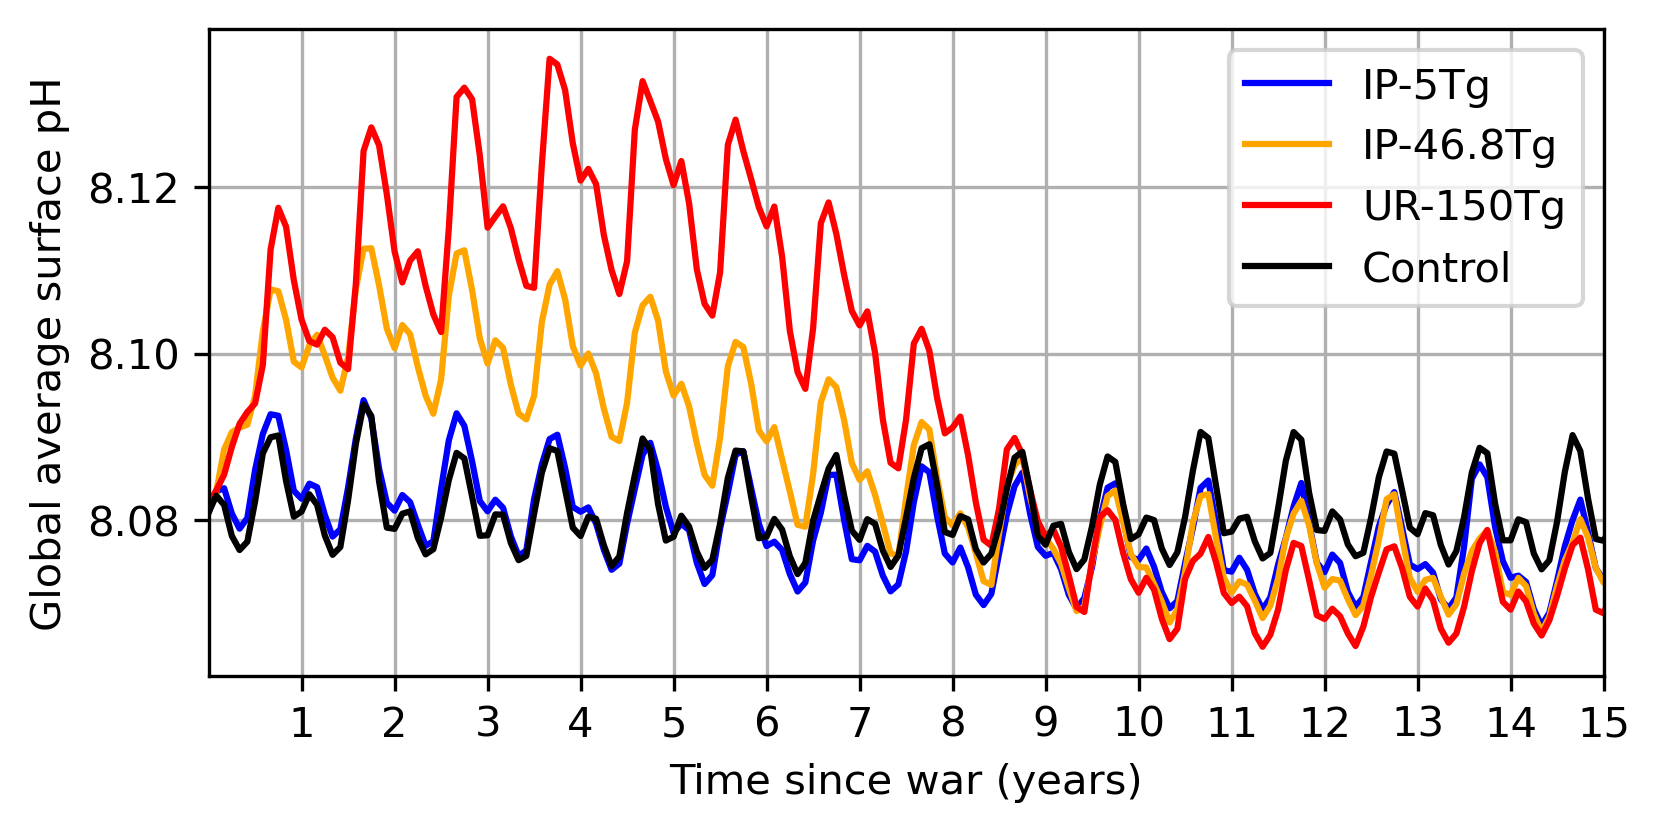

In [7]:
case_labels={}; color_labels={}; double_or_nothing={}
case_labels['fosi_ip_5tg_01_alluv']='IP-5Tg'; color_labels['fosi_ip_5tg_01_alluv']='blue'; double_or_nothing['fosi_ip_5tg_01_alluv']=1
case_labels['fosi_ip_46p8_01_alluv']='IP-46.8Tg'; color_labels['fosi_ip_46p8_01_alluv']='orange'; double_or_nothing['fosi_ip_46p8_01_alluv']=1
case_labels['fosi_ur_150tg_01_alluv']='UR-150Tg'; color_labels['fosi_ur_150tg_01_alluv']='r'; double_or_nothing['fosi_ur_150tg_01_alluv']=1
case_labels['nw_cntrl_tuv_01']='Control'; color_labels['nw_cntrl_tuv_01']='k'; double_or_nothing['nw_cntrl_tuv_01']=2
these_cases=['fosi_ip_5tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ur_150tg_01_alluv','nw_cntrl_tuv_01']; 




var='PH'
plt.figure(figsize=[6,2.8])
for case in these_cases:
    plot_data = monthly_data[case][var]#*double_or_nothing[case]
    ts = np.linspace(1, len(plot_data),len(plot_data)) * (1/12.0) + (-4 * (1/12.0))
    plt.plot(ts,plot_data,label=case_labels[case],color=color_labels[case])
    
plt.xlabel('Time since war (years)'); plt.ylabel('Global average surface pH'); plt.legend(loc='best'); plt.grid()
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20')); plt.xlim([0,15])
plt.show()

In [ ]:
#
#
#
# DIC PANEL
#
#
#

In [8]:
#Option 1: run this block if DIC is available
these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['DIC']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   
def compute_global_weighted_mean_3D(ds,var='DIC'): 
    z = ds[var].isel(z_t=0)
    A = ds["TAREA"] * 1e-4   # cm² → m²
    weights = A.where(z.notnull())
    weights = A.fillna(0)
    ds_weighted = z.weighted(weights)
    weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values

   
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    for var in these_variables:
        ds = xr.open_mfdataset(files[case][var])
        monthly_data[case][var] = compute_global_weighted_mean_3D(ds,var=var)

In [12]:
#Option 2: Run this block when DIC has been pre-processed to DIC_sfc
these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['DIC_sfc']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   
def compute_global_weighted_mean_sfc(ds,var='DIC_sfc'): 
    z = ds[var]
    A = ds["TAREA"] * 1e-4   # cm² → m²
    weights = A.where(z.notnull())
    weights = A.fillna(0)
    ds_weighted = z.weighted(weights)
    weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values

   
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    for var in these_variables:
        ds = xr.open_mfdataset(files[case][var])
        monthly_data[case][var] = compute_global_weighted_mean_sfc(ds,var=var)

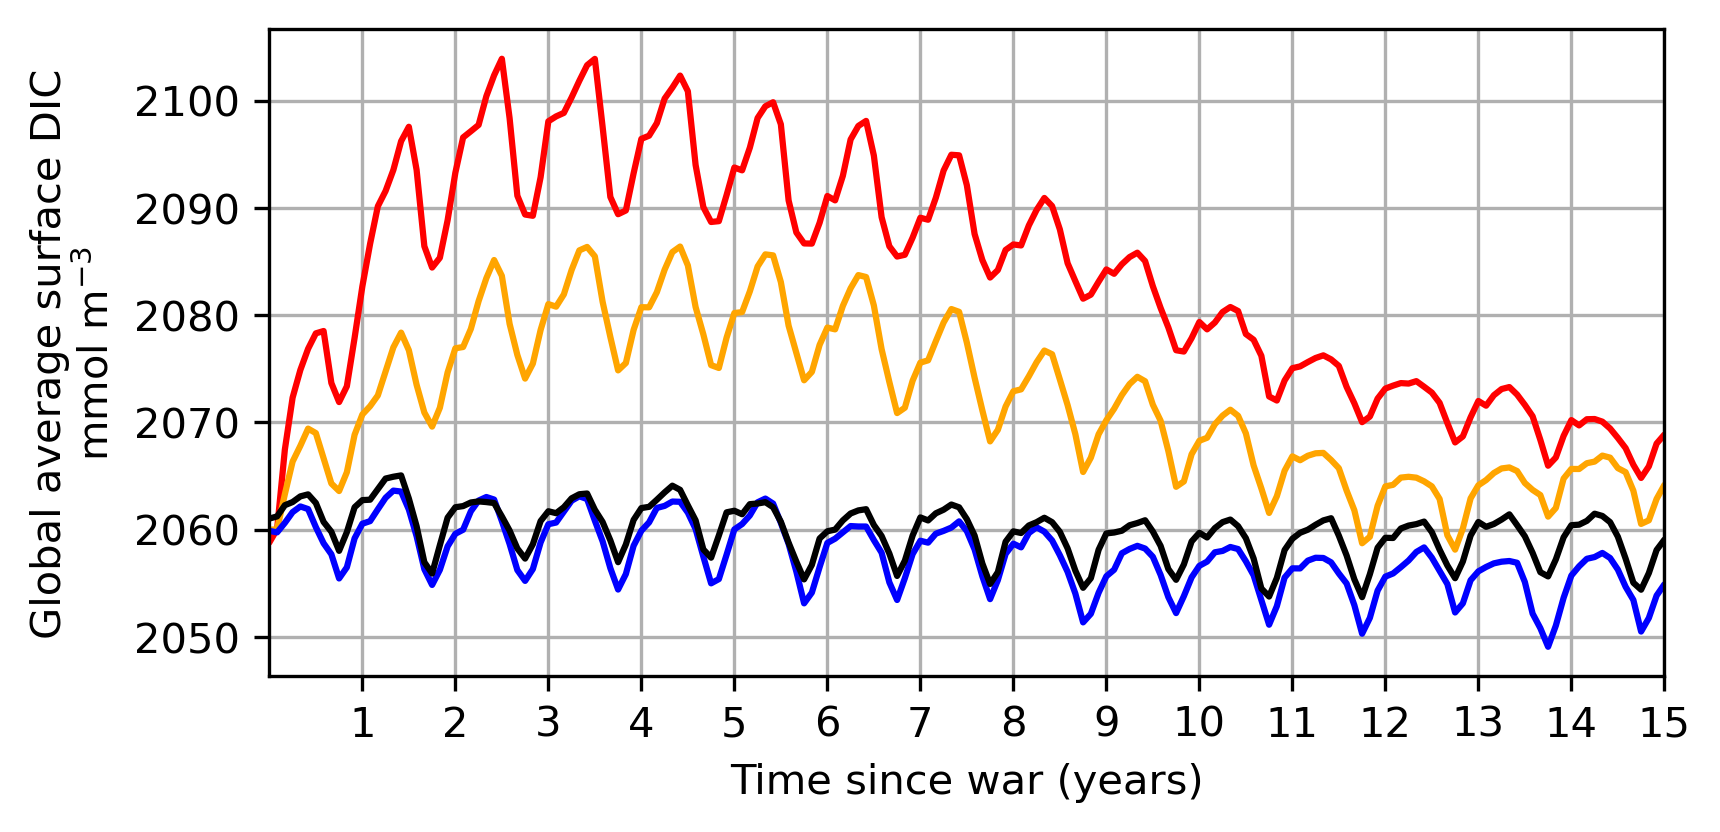

In [13]:

    
#var='DIC'
var='DIC_sfc'
plt.figure(figsize=[6,2.8])
for case in these_cases:
    plot_data = monthly_data[case][var]#*double_or_nothing[case]
    ts = np.linspace(1, len(plot_data),len(plot_data))
    ts = np.linspace(1, len(plot_data),len(plot_data)) * (1/12.0) + (-4 * (1/12.0))
    plt.plot(ts,plot_data,label=case_labels[case],color=color_labels[case])
    
plt.xlabel('Time since war (years)'); plt.ylabel('Global average surface DIC\nmmol m$^{-3}$'); #plt.legend(loc='best'); 
plt.grid()
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20')); plt.xlim([0,15])
plt.show()
    

In [ ]:
#
#
# omega calcite panel
#
#
#

In [16]:
# Option 1: if provided co3_sat_calc and CO3, run this block

these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['co3_sat_calc','CO3']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   
# tempdata_CO3/tempdata

def compute_global_weighted_mean_omega_calcite(ds): 
    CO3 = ds['CO3'].isel(z_t=0)
    co3_sat_calc = ds['co3_sat_calc'].isel(z_t=0)
    omega_calcite = CO3 / co3_sat_calc
    
    A = ds["TAREA"] * 1e-4   # cm² → m²
    weights = A.where(omega_calcite.notnull())
    weights = A.fillna(0)
    ds_weighted = omega_calcite.weighted(weights)
    weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values

   
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    ds={}
    for var in these_variables:
        ds[var] = xr.open_mfdataset(files[case][var]) 
    ds_combined = xr.merge([ ds[ these_variables[0] ], ds[ these_variables[1] ] ])
    monthly_data[case]['omega_calcite'] = compute_global_weighted_mean_omega_calcite(ds_combined)

In [19]:
#Option 2: if omega_calcite data is available in data archive, run this instead
these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['omega_calcite']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))



def compute_global_weighted_mean_sfc(ds,var='omega_calcite'): 
    z = ds[var]
    A = ds["TAREA"] * 1e-4   # cm² → m²
    weights = A.where(z.notnull())
    weights = A.fillna(0)
    ds_weighted = z.weighted(weights)
    weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values

   
monthly_data={}
for case in these_cases:
    monthly_data[case]={}
    for var in these_variables:
        ds = xr.open_mfdataset(files[case][var])
        monthly_data[case][var] = compute_global_weighted_mean_sfc(ds,var=var)

/tmp/ipykernel_3730105/494231354.py:22: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ ds[ these_variables[0] ], ds[ these_variables[1] ] ])
/tmp/ipykernel_3730105/494231354.py:22: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ ds[ these_variables[0] ], ds[ these_variables[1] ] ])
/tmp/i

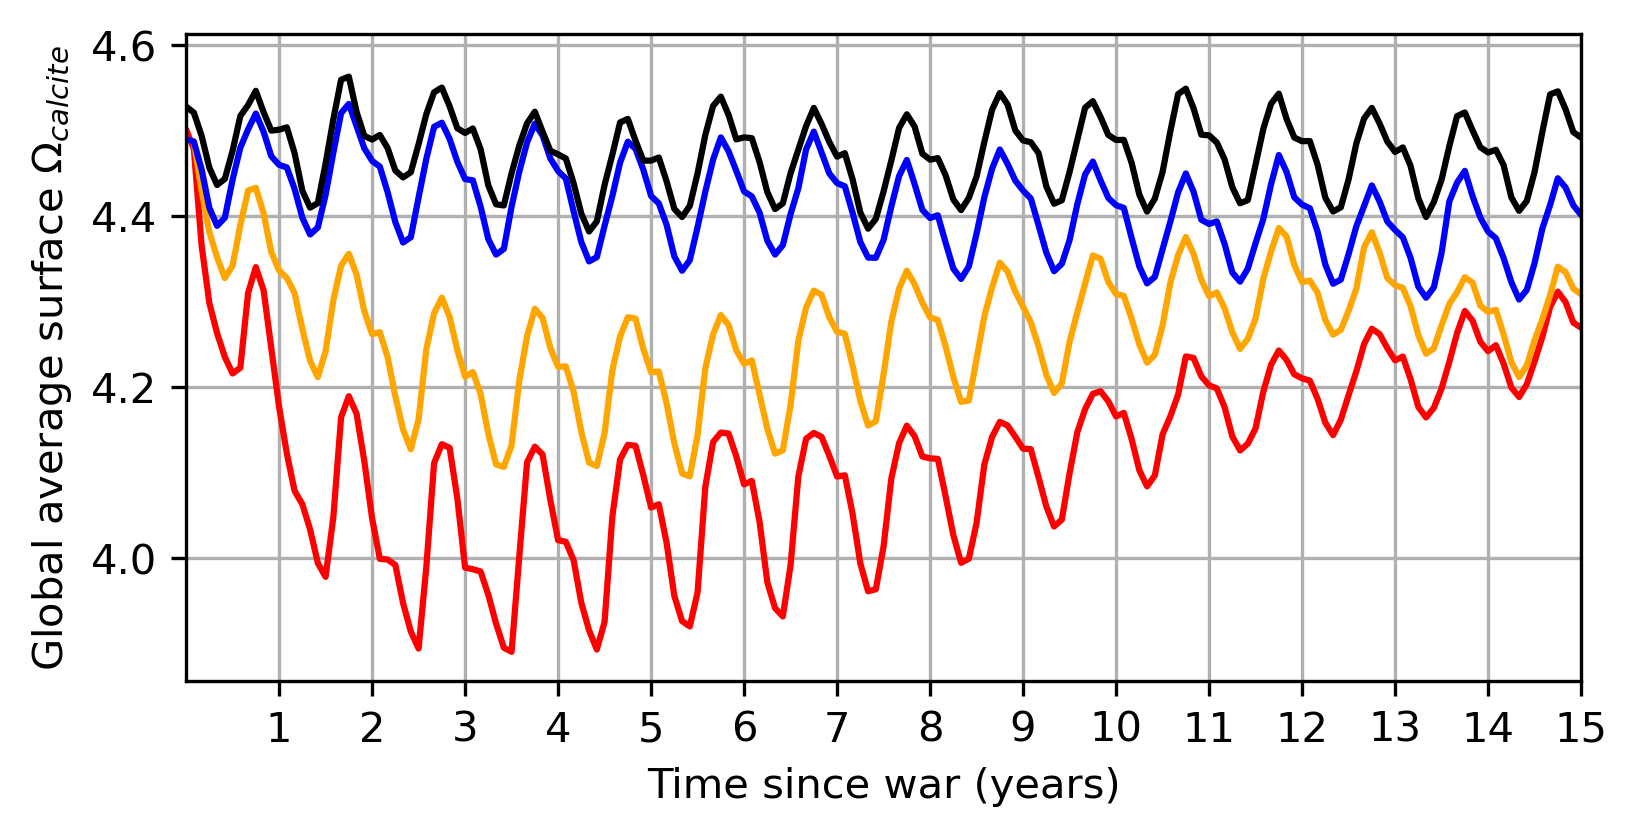

In [21]:

var='omega_calcite'
plt.figure(figsize=[6,2.8])
for case in these_cases:
    plot_data = monthly_data[case][var]#*double_or_nothing[case]
    ts = np.linspace(1, len(plot_data),len(plot_data))
    ts = np.linspace(1, len(plot_data),len(plot_data)) * (1/12.0) + (-4 * (1/12.0))
    plt.plot(ts,plot_data,label=case_labels[case],color=color_labels[case])
    
plt.xlabel('Time since war (years)'); plt.ylabel('Global average surface $\Omega$$_{calcite}$'); #plt.legend(loc='best'); 
plt.grid()
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20')); plt.xlim([0,15])
plt.show()
    

In [ ]:
# pic/poc ['coccoC','coccoCaCO3']

In [33]:
# option 1: if coccoC and coccoCaCO3 are available (they will not be on zenodo)
these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'

these_variables=['coccoC','coccoCaCO3'] # may not be available on zenodo because of storage restrictions

files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   

def compute_area_weighted_mean_picpoc(ds,weighting_type='weight_by_biomass'): 
    pic = ds['coccoCaCO3'].isel(z_t_150m=0)
    poc = ds['coccoC'].isel(z_t_150m=0)
    pic_poc = pic / poc
    
    if weighting_type == 'weight_by_biomass':
        weights = poc.where(poc.notnull())
        weights = weights.fillna(0)
        ds_weighted = pic_poc.weighted(weights) # weigh by coccolithophore biomass
        weighted_mean = ds_weighted.mean(("nlat","nlon"))
    else:
        A = ds["TAREA"] * 1e-4   # cm² → m²
        weights = A.where(pic_poc.notnull())
        weights = weights.fillna(0)
        ds_weighted = pic_poc.weighted(weights) # weight by area 
        weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values
        

   
monthly_data={}
for case in these_cases[:]:
    monthly_data[case]={}
    ds={}
    for var in these_variables:
        ds[var] = xr.open_mfdataset(files[case][var]) 
    ds_combined = xr.merge([ ds[ these_variables[0] ], ds[ these_variables[1] ] ])
    monthly_data[case]['picpoc'] = compute_area_weighted_mean_picpoc(ds_combined)

In [35]:
# Option 2: use picpoc files directly

these_cases=['fosi_ur_150tg_01_alluv','fosi_ip_46p8_01_alluv','fosi_ip_5tg_01_alluv','nw_cntrl_tuv_01']#these_cases=['fosi_ur_150tg_01_alluv','nw_ip_5tg_tuv_ens01','nw_ip_46p8_tuv_ens01','nw_ur_150_tuv_01','nw_cntrl_tuv_01']']
#these_cases=['nw_ur_150_tuv_01','nw_ip_46p8_tuv_ens01','nw_ip_5tg_tuv_ens01','nw_cntrl_tuv_01']
data_directory = '/scratch/alpine/joco6825/cesm/nw_cases/archive/manuscript_data/'


these_variables=['picpoc','coccoC_sfc']


files={}
for case in these_cases:
    files[case]={}
    for VAR in these_variables:
        files[case][VAR]=sorted(glob.glob(data_directory+case+'/'+case+'.pop.h.'+VAR+'.*.nc'))

   

def compute_area_weighted_mean_picpoc(ds,weighting_type='weight_by_biomass'): 
    poc = ds['coccoC_sfc']
    pic_poc = ds['picpoc']

    if weighting_type == 'weight_by_biomass':
        weights = poc.where(poc.notnull())
        weights = weights.fillna(0)
        ds_weighted = pic_poc.weighted(weights) # weigh by coccolithophore biomass
        weighted_mean = ds_weighted.mean(("nlat","nlon"))
    else:
        A = ds["TAREA"] * 1e-4   # cm² → m²
        weights = A.where(pic_poc.notnull())
        weights = weights.fillna(0)
        ds_weighted = pic_poc.weighted(weights) # weight by area 
        weighted_mean = ds_weighted.mean(("nlat","nlon"))
    return weighted_mean.values
        

   
monthly_data={}
for case in these_cases[:]:
    monthly_data[case]={}
    ds={}
    for var in these_variables:
        ds[var] = xr.open_mfdataset(files[case][var]) 
    ds_combined = xr.merge([ ds[ these_variables[0] ], ds[ these_variables[1] ] ])
    monthly_data[case]['picpoc'] = compute_area_weighted_mean_picpoc(ds_combined)

/tmp/ipykernel_3730105/1976853661.py:28: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ ds[ these_variables[0] ], ds[ these_variables[1] ] ])
/tmp/ipykernel_3730105/1976853661.py:28: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ ds[ these_variables[0] ], ds[ these_variables[1] ] ])
/tmp

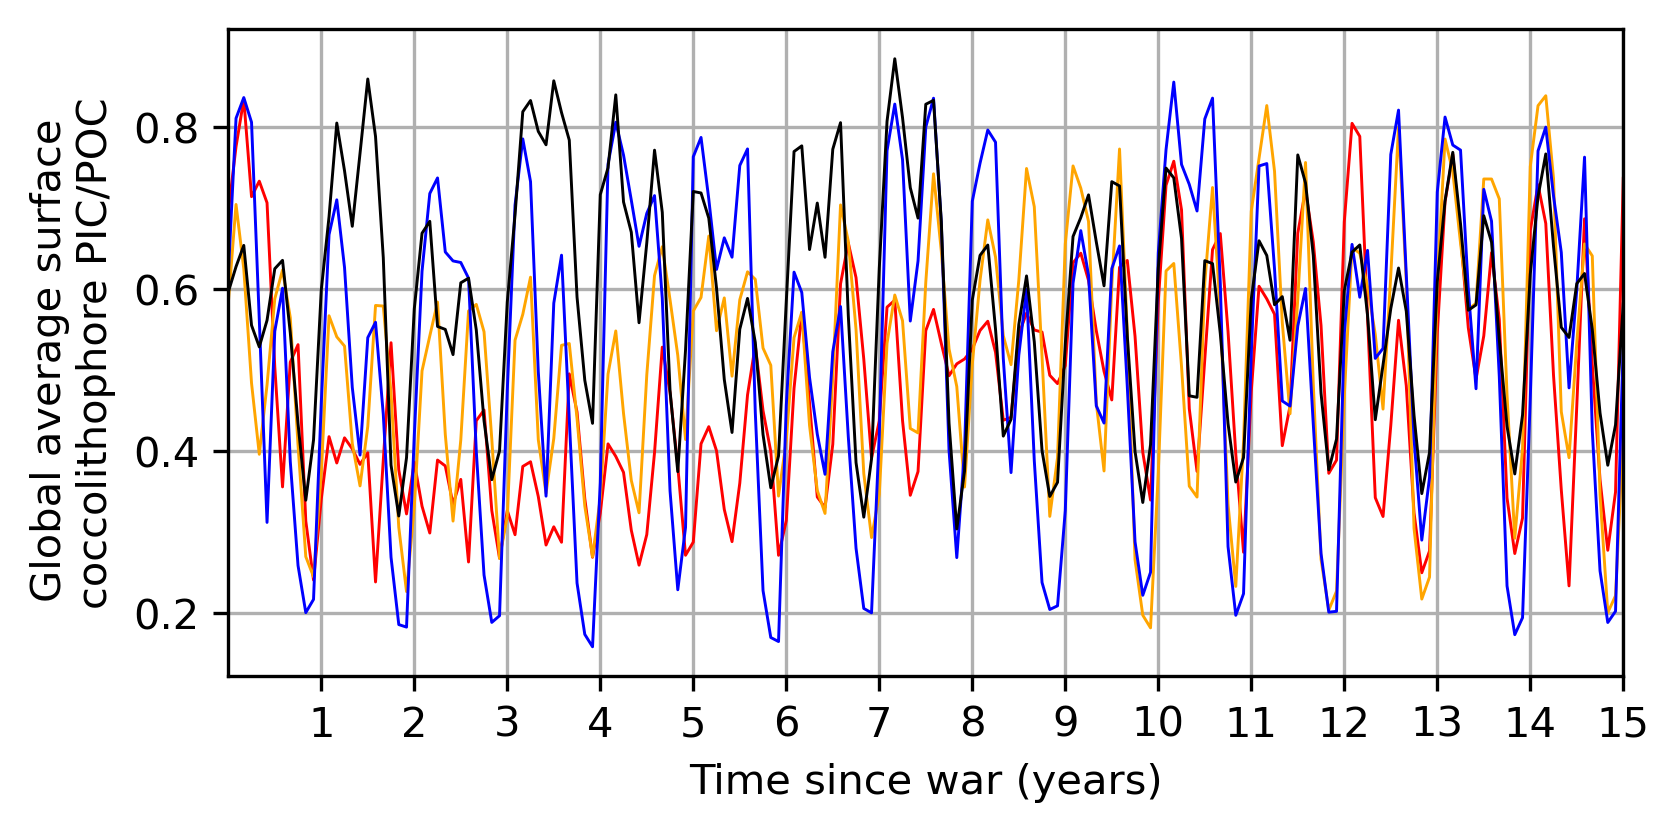

In [37]:
# default is coccolithophore biomass weighted
var='picpoc'
plt.figure(figsize=[6,2.8])
for case in these_cases:
    plot_data = monthly_data[case][var]#*double_or_nothing[case]
    ts = np.linspace(1, len(plot_data),len(plot_data))
    ts = np.linspace(1, len(plot_data),len(plot_data)) * (1/12.0) + (-4 * (1/12.0))
    #plt.plot(ts,plot_data,label=case_labels[case],linewidth=0-.7)
    plt.plot(ts,plot_data,label=case_labels[case],color=color_labels[case],linewidth=.7)
    
plt.xlabel('Time since war (years)'); plt.ylabel('Global average surface \ncoccolithophore PIC/POC'); #plt.legend(loc='best'); 
plt.grid()
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20],('1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20')); plt.xlim([0,15])
plt.show()